- Forecast total revenue
  - Predict total revenue for a booking to use dynamic pricing (regression)

--------------------

Regression is a supervised machine learning method that uses the relationship between variables to get a prediction

The label that will be predicted is the total revenue label to predict understand how features influence total revenue and how the business can use that understanding to increase revenue through dynamic pricing

The select variables are:
- Total nights: which indicates how long a customer makes a booking for

-------------------------

The procesed used to model and evaluate is as follows:
1. Load necessary libraries
2. Identify the target (Total Revenue)
3. Feature engineer
4. Encode categorical variables (may not be necessary for this investigation)
5. Split the data
6. Train the model
7. Evaluate the model

The three selected models are:
- Linear regression - model calculates the propbability of an event occuring by using a straight line of best fit.
- Polynomial regression - the model fits data into a polynomial equation and allows for predictions to be made by following the curved line of best fit

---------------------------

1. Load necessary libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.metrics import mean_squared_error , mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import make_pipeline

In [2]:
data = pd.read_csv('hotel_bookings.csv')

3. Feature engineer

In [ ]:
data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
data['total_revenue'] = data['adr'] * data['total_nights']

5. Splitting the data

In [10]:
X = data[['total_nights']]
y = data[['total_revenue']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

6. Train the model

Model 1: Linear regression

In [11]:
lin_reg = LinearRegression() # Create linear regression
lin_reg.fit(X_train,y_train) # Fit the linear regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
pred = lin_reg.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test,pred))

7. Evaluate the model

In [13]:
lin_rmse = np.sqrt(mean_squared_error(y_test, pred))
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)

print("Linear Regression Results")
print("RMSE:", lin_rmse)
print("MAE:", lin_mae)
print("R²:", lin_r2)

Linear Regression Results
RMSE: 220.30716463942065
MAE: 130.5047537016776
R²: 0.570922408886569


- RMSE (Root mean squared) measures the magnitude of errors between the predicted values and the actual values. it calculates the difference between the predicted value and the actual value (residual). Then square the residuaals to remove negative values. Following that, find the mean and then square root the value to find the root mean squared error. When comparing performance using RMSE, the model with a lower RMSE performs better. The model has a high RMSE score, which can be explained by the fact that the dataset is large.
- MAE (Mean absolute error) is a statistical measure for prediction accuracy by calculating absolute difference between predicted and actual values. The closer this value is to 0 the better the model performs. The model has a also high MAE score, which can be explained by the above reason.
- R² (coefficient of determination) measures how much of the total variation in the dependant variable is acounted for / explained by the predictor  (0.0 - the model does not explain the variability, 1.0 - the model explains 100% the variability). The model explains 57% of variability.

In [30]:
# coefficients: 
# View the intercept
print ('intercept value is: ', lin_reg.intercept_)

# 5 - View the feature coefficient - in our case we have only one coefficient
print ('Slope value is ', lin_reg.coef_)

intercept value is:  [22.6490905]
Slope value is  [[97.80750271]]


The intercept value indicates that when total nighst is 0, Total revenue is predictied to be £22.64 (a very low value). This is a fair prediction as when customer does not book, then the business will have no revenue due to there being no business being done.
The slope value highlights that as the nights increase the revenue increases by £97.81. With this information, the business could consider encouraging longer stays to increase revenue.

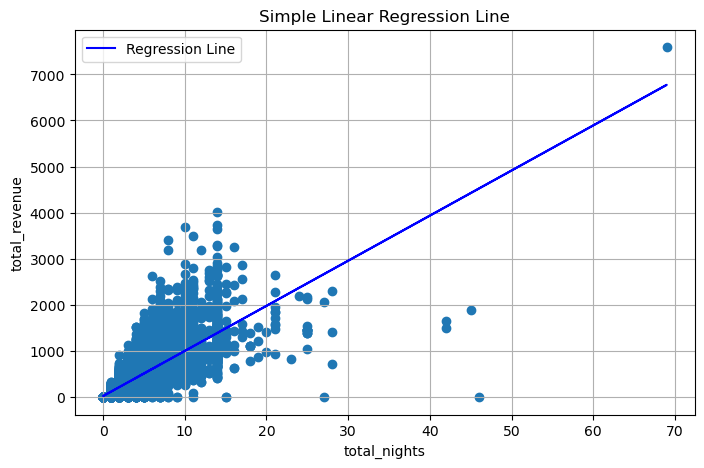

In [15]:
# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test)
plt.plot(X_test, pred, label='Regression Line', color='blue')
plt.title('Simple Linear Regression Line')
plt.xlabel('total_nights')
plt.ylabel('total_revenue')
plt.grid(True)
plt.legend()
plt.show()

6. Train the model

Model 2: Polynomial regression

In [16]:
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

X = data[['total_nights']]
y = data[['total_revenue']]


7. Evaluate the model

In [ ]:
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())  # make_pipeline - This connects these steps into a single object (a pipeline).

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipeline.fit(X_train,y_train)

pred = pipeline.predict(X_test)


print("Polynomial Regression Results")

poly_rmse = np.sqrt(mean_squared_error(y_test, pred))
poly_mae = mean_absolute_error(y_test, pred)
poly_r2 = r2_score(y_test, pred)


print("RMSE:", poly_rmse)
print("MAE:", poly_mae)
print("R²:", poly_r2)

Polynomial Regression Results
RMSE: 224.51943189290398
MAE: 130.7694378849139
R²: 0.568801407035447


- RMSE (Root mean squared) measures the magnitude of errors between the predicted values and the actual values. it calculates the difference between the predicted value and the actual value (residual). Then square the residuaals to remove negative values. Following that, find the mean and then square root the value to find the root mean squared error. When comparing performance using RMSE, the model with a lower RMSE performs better. The model has a high RMSE score, which can be explained by the fact that the dataset is large. Although this figure is lower than the linear regression model and therefore outperforms it.
- MAE (Mean absolute error) is a statistical measure for prediction accuracy by calculating absolute difference between predicted and actual values. The closer this value is to 0 the better the model performs. The model has a also high MAE score, which can be explained by the above reason. Although this result is higher than the linear regression model.
- R² (coefficient of determination) measures how much of the total variation in the dependant variable is acounted for / explained by the predictor  (0.0 - the model does not explain the variability, 1.0 - the model explains 100% the variability). The model explains 56% of variability, meaning it has performed underperfomed in comparison to the linear regression graph

Overall, this model underperfoms incomparison to linear regression.

In [63]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


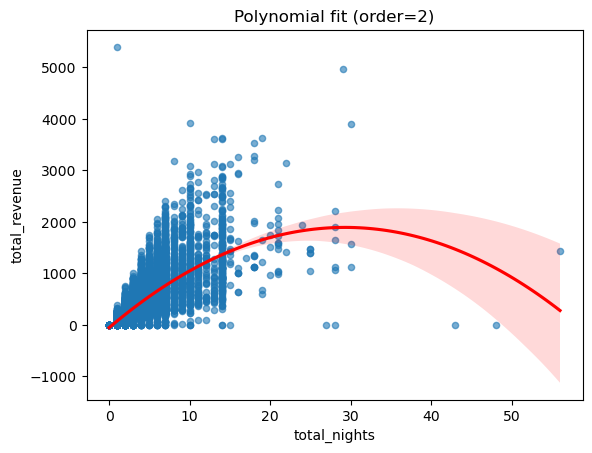

In [ ]:
import seaborn as sns
sns.regplot(x=X_test.values.flatten(), y=y_test.values.flatten(), order=2,
            scatter_kws={'s':20, 'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('total_nights'); plt.ylabel('total_revenue'); plt.title('Polynomial fit of degree 2')
plt.show()

This graph indicates that the total nights that produces the highest amount of revnue is around 29 nights. with this information the company and use dynamic pricing for bookings that are made for 25-35 nights in order to increase revenue.